# XGBoost Models (All WorkCodes)
Compare with/without distance + block size analysis

In [1]:

import pandas as pd
import numpy as np
import time

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from feature_engineer import get_engineered_df_allWC

In [2]:

DATA_PATH = "../data/processed/rt_detailed.parquet"
WAREHOUSE = "RT"
MAX_TIME = 300

df, features_all, cat_cols = get_engineered_df_allWC(
    file_path=DATA_PATH,
    warehouse=WAREHOUSE,
    max_time=MAX_TIME
)

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["date"] = df["Timestamp"].dt.date

print(df.shape)

(80678, 41)


In [3]:

distance_features = ["Travel_Distance", "log_travel_distance", "same_aisle", "same_location", "diff_level"]

features_with_dist = features_all
features_no_dist = [f for f in features_all if f not in distance_features]

cat_cols_no_dist = [c for c in cat_cols if c not in ["same_aisle", "same_location", "diff_level"]]

In [12]:

def split_chrono(df, ratio=0.2):
    days = sorted(df["date"].unique())
    n_test = max(1, int(len(days)*ratio))
    test_days = days[-n_test:]
    train = df[df["date"] < test_days[0]].copy()
    test = df[df["date"].isin(test_days)].copy()
    return train, test

train_df, test_df = split_chrono(df)

y_train = train_df["Time_Delta_sec"]
y_test = test_df["Time_Delta_sec"]

In [13]:
# number of days for test set and train
n_test_days = test_df["date"].nunique()
n_train_days = train_df["date"].nunique()
print(f"Train days: {n_train_days}, Test days: {n_test_days}")

Train days: 11, Test days: 2


In [14]:

def make_X(train, test, features, cat_cols):
    X_train = pd.get_dummies(train[features], columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(test[features], columns=cat_cols, drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    return X_train, X_test

In [15]:

results = []

for label, feats, cats in [
    ("with_distance", features_with_dist, cat_cols),
    ("no_distance", features_no_dist, cat_cols_no_dist)
]:
    X_train, X_test = make_X(train_df, test_df, feats, cats)

    t0 = time.time()
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    runtime = time.time() - t0

    results.append({
        "Model": label,
        "R2": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Runtime": runtime
    })

pd.DataFrame(results)

,Model,R2,MAE,RMSE,Runtime
0,with_distance,0.359665,18.139715,28.990885,1.095471
1,no_distance,0.269340,20.303728,30.968189,0.819093


In [16]:
def make_blocks(df, block_size):
    df = df.sort_values(["UserID", "Timestamp"])
    blocks = []
    for (uid, d), g in df.groupby(["UserID","date"]):
        for i in range(0, len(g), block_size):
            chunk = g.iloc[i:i+block_size]
            if len(chunk)==block_size:
                blocks.append(chunk)
    return blocks

In [22]:
# ----------------------------
# Train model ONCE
# ----------------------------
X_train, X_test = make_X(train_df, test_df, features_no_dist, cat_cols_no_dist)
model = XGBRegressor(
    n_estimators=800,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
test_df = test_df.copy()
test_df["pred_no_dist"] = model.predict(X_test)

# ----------------------------
# Block evaluation
# ----------------------------
block_sizes = [1, 5, 10, 15, 20, 30, 40, 50]
block_results = []

for bs in block_sizes:
    blocks = make_blocks(test_df, bs)

    actual = []
    pred = []

    for b in blocks:
        actual.append(b["Time_Delta_sec"].sum())
        pred.append(b["pred_no_dist"].sum()) 

    block_results.append({
        "BlockSize": bs,
        "NumBlocks": len(blocks),
        "MAE": mean_absolute_error(actual, pred),
        "MAE_per_task": mean_absolute_error(actual, pred) / bs
    })

In [23]:
# MAE and MAE_per_task to 3 digits
for r in block_results:
    r["MAE"] = round(r["MAE"], 3)

pd.DataFrame(block_results).sort_values("BlockSize")

,BlockSize,NumBlocks,MAE,MAE_per_task
0,1,12339,21.285,21.284999
1,5,2434,62.171,12.434137
2,10,1194,102.525,10.252502
3,15,783,138.126,9.208430
4,20,576,168.878,8.443905
5,30,372,241.590,8.053015
6,40,268,288.263,7.206569
7,50,208,366.032,7.320631


In [24]:
# with dist
X_train_dist, X_test_dist = make_X(train_df, test_df, features_with_dist, cat_cols)
model = XGBRegressor(
    n_estimators=800,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_dist, y_train)  # Refit with distance features
test_df["pred_with_dist"] = model.predict(X_test_dist)

# A dictionary of means for each WC from train_df
workcode_means = train_df.groupby("WorkCode")["Time_Delta_sec"].mean()
test_df["workcode_mean_pred"] = test_df["WorkCode"].map(workcode_means)

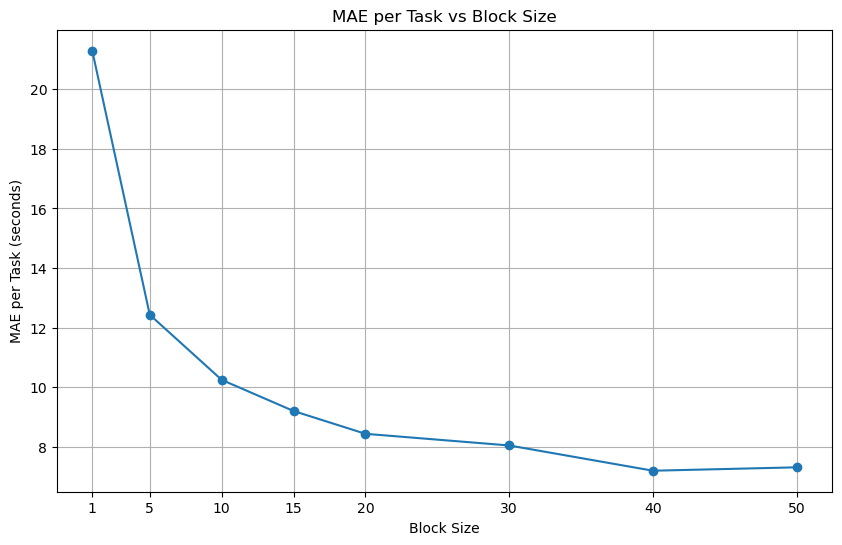

In [25]:
# Plot the MAE_per_task vs BlockSize as a line chart
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,6))
plt.plot([r["BlockSize"] for r in block_results], [r["MAE_per_task"] for r in block_results], marker='o')
plt.xlabel("Block Size")
plt.ylabel("MAE per Task (seconds)")
plt.title("MAE per Task vs Block Size")
plt.xticks(block_sizes)
plt.grid()
plt.show()

In [27]:
# For chunks of size 20, table compring mae pertask for WC mean, XGB with dist, XGB no dist
bs = 20
blocks = make_blocks(test_df, bs)
actual = []
pred_no_dist = []
pred_with_dist = []
pred_wc_mean = []
for b in blocks:
    actual.append(b["Time_Delta_sec"].sum())
    pred_no_dist.append(b["pred_no_dist"].sum()) 
    pred_with_dist.append(b["pred_with_dist"].sum()) 
    pred_wc_mean.append(b["workcode_mean_pred"].sum())
print(f"MAE per task (predict WC mean): {mean_absolute_error(actual, pred_wc_mean) / bs:.3f} seconds")
print(f"MAE per task (XGB with dist): {mean_absolute_error(actual, pred_with_dist) / bs:.3f} seconds")
print(f"MAE per task (XGB no dist): {mean_absolute_error(actual, pred_no_dist) / bs:.3f} seconds")

MAE per task (predict WC mean): 9.546 seconds
MAE per task (XGB with dist): 8.086 seconds
MAE per task (XGB no dist): 8.444 seconds
